In [ ]:
import matplotlib.pyplot as plt
import numpy

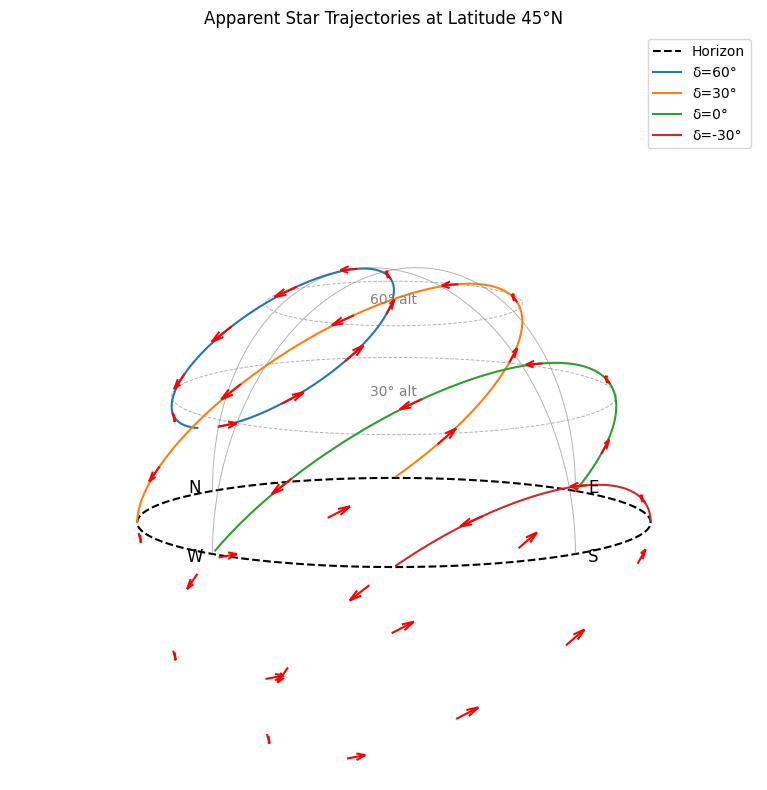

In [ ]:
import numpy as np
import matplotlib.pyplot as plt

# Observer latitude (medium latitude)
latitude_deg = 45.0
lat = np.radians(latitude_deg)

# ---- Helper: Convert RA/Dec to alt-az Cartesian ----
def radec_to_altaz_cart(ra_hours, dec_deg, lst_hours, lat_rad):
    ha_deg = (lst_hours - ra_hours) * 15.0  # hour angle in degrees
    ha = np.radians(ha_deg)
    dec = np.radians(dec_deg)
    alt = np.arcsin(np.sin(lat_rad)*np.sin(dec) + np.cos(lat_rad)*np.cos(dec)*np.cos(ha))
    az = np.arctan2(-np.sin(ha), np.cos(lat_rad)*np.tan(dec) - np.sin(lat_rad)*np.cos(ha))
    # Cartesian conversion (z up)
    x = np.cos(alt) * np.sin(az)
    y = np.cos(alt) * np.cos(az)
    z = np.sin(alt)
    return x, y, z

# ---- Build Figure ----
fig = plt.figure(figsize=(8,8))
ax = fig.add_subplot(111, projection='3d')
ax.set_proj_type('ortho')
ax.set_box_aspect([1,1,0.5])

# Horizon circle (z=0)
theta = np.linspace(0, 2*np.pi, 400)
ax.plot(np.cos(theta), np.sin(theta), np.zeros_like(theta), 'k--', lw=1.5, label='Horizon')

# Cardinal direction labels (E,N,W,S)
labels = {'E':(1.1,0,0), 'N':(0,1.1,0), 'W':(-1.1,0,0), 'S':(0,-1.1,0)}
for txt,(x,y,z) in labels.items():
    ax.text(x, y, z, txt, ha='center', va='center', fontsize=12)

# Draw altitude circles (like 30°, 60° above horizon)
altitudes = np.radians([30, 60])
for alt in altitudes:
    r = np.cos(alt)
    z = np.sin(alt)
    ax.plot(r*np.cos(theta), r*np.sin(theta), np.full_like(theta,z), 
            '--', lw=0.7, color='gray', alpha=0.6)
    ax.text(0,0,z, f'{np.degrees(alt):.0f}° alt', color='gray', ha='center')

# Draw azimuth meridians (0°=N,90°=E,etc)
azimuths = np.radians([0,90,180,270])
for az in azimuths:
    alt = np.linspace(0, np.pi/2, 100)
    x = np.cos(alt)*np.sin(az)
    y = np.cos(alt)*np.cos(az)
    z = np.sin(alt)
    ax.plot(x, y, z, color='gray', lw=0.7, alpha=0.6)

# ---- Plot several star trajectories (constant Dec circles) ----
ras = np.linspace(12, -11, 200)
for dec_deg in [60, 30, 0, -30]:
    xs, ys, zs = [], [], []
    for ra in ras:
        x,y,z = radec_to_altaz_cart(ra, dec_deg, lst_hours=0, lat_rad=lat)
        xs.append(x); ys.append(y); zs.append(z)
    # keep only points above horizon
    xs, ys, zs = np.array(xs), np.array(ys), np.array(zs)
    above = zs >= 0
    ax.plot(xs[above], ys[above], zs[above], lw=1.5, label=f"δ={dec_deg}°")

    dx = np.gradient(xs)
    dy = np.gradient(ys)
    dz = np.gradient(zs)

    # Add arrows along the path
    skip = 20  # plot every 5 points to avoid clutter
    ax.quiver(xs[::skip], ys[::skip], zs[::skip], 
            dx[::skip], dy[::skip], dz[::skip], 
            length=0.1, normalize=True, color='red', arrow_length_ratio=0.5)

# ---- Labels & cosmetics ----
ax.set_title(f"Apparent Star Trajectories at Latitude {latitude_deg:.0f}°N")
ax.set_xlabel('East-West (x)')
ax.set_ylabel('North-South (y)')
ax.set_zlabel('Altitude (z)')
ax.legend()
ax.set_xlim(-1,1)
ax.set_ylim(-1,1)
ax.set_zlim(0,1)
ax.set_axis_off()
ax.view_init(elev=10, azim=-135)
plt.tight_layout()
plt.show()


In [ ]:
from HARey.curved_text import curved_text
from HARey.astro_functions import ecliptic2radec
import numpy as np
import matplotlib.pyplot as plt

import numpy as np
from matplotlib.text import TextPath
from matplotlib.patches import PathPatch, Circle
from matplotlib.transforms import Affine2D

from matplotlib.markers import MarkerStyle

In [ ]:

from HARey.harey_main import HAReyMain
harey = HAReyMain()

Loading constellations diagrams....     Done!
Loading star coordinates....     Done!
Computing stars colors...     Done!
Loading custom markers....       Done!
Loading the object names....       Done!


Using the tarot-round format, 2.75x4.75 in, using the template at None


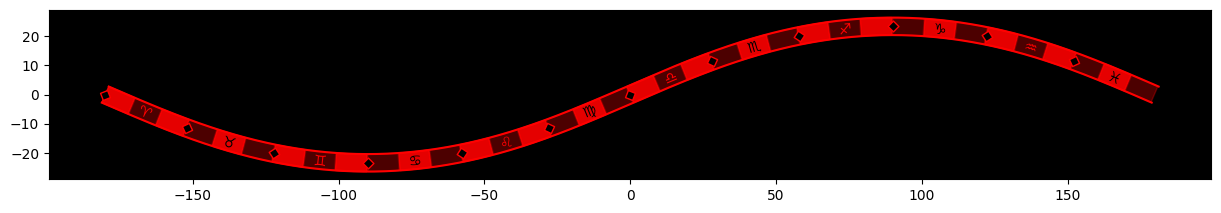

In [ ]:
from matplotlib.markers import MarkerStyle


n_points = 1440
length = 10
d = int(n_points/360*10)
ecl_x, ecl_y = ecliptic2radec(np.linspace(-180, 180, n_points+1), np.zeros(n_points+1))

dx = np.gradient(ecl_x)
dy = np.gradient(ecl_y)
l = np.sqrt(dx**2 + dy**2)
nx, ny = dy/l, -dx/l
w = 3
x1, x2 = ecl_x + w*nx, ecl_x - w*nx
y1, y2 = ecl_y + w*ny, ecl_y - w*ny

fig, ax = plt.subplots(1,1, figsize=(15,4))
ax.set_facecolor('k')
ax.plot(x1, y1, 'r')
ax.plot(x2, y2, 'r')

segments = [[x1[i:i+d], x2[i:i+d], y1[i:i+d], y2[i:i+d]] for i in range(0, n_points,d)]

for i, segment in enumerate(segments):
    alpha = 0.9 if i%2==0 else 0.3
    ax.fill(np.concatenate([segment[0], segment[1][::-1]]), np.concatenate([segment[2], segment[3][::-1]]), color='r', alpha=alpha)

zodiac_symbols = ['\u2648', '\u2649', '\u264A', '\u264B', '\u264C', '\u264D','\u264E', '\u264F', '\u2650', '\u2651', '\u2652', '\u2653']

for i, (text, t) in enumerate(zip(zodiac_symbols, range(int(n_points/360*15), n_points, int(n_points/360*30)))):
    #circle = Circle((ecl_x[t], ecl_y[t]), radius=2, edgecolor='r', facecolor = 'w', fill=True)
    #ax.add_patch(circle)
    text_path = TextPath((0, 0), text, size=5)
    bb = text_path.get_extents()
    # Center the text path
    text_centered = Affine2D().translate(-0.5 * (bb.x0 + bb.x1), -0.5 * (bb.y0 + bb.y1)).transform_path(text_path)
    text_rotated = Affine2D().rotate(np.atan2(dy[t], dx[t])).transform_path(text_centered)
    text_translated = Affine2D().translate(ecl_x[t], ecl_y[t]).transform_path(text_rotated)
    color = 'r' if i%2==0 else 'k'
    patch = PathPatch(text_translated, color=color, linewidth=0)
    ax.add_patch(patch)

for i in range(0, n_points, int(n_points/360*30)):
    t = Affine2D().rotate(np.atan2(dy[i], dx[i]))
    ax.scatter(ecl_x[i], ecl_y[i], s=30, marker=MarkerStyle('D', transform=t), edgecolor='r', facecolor='k')

ax.set_aspect('equal')

In [ ]:
con_names = [harey.names[id] for id in harey.con_ids]
sorted_IDs = [id for _, id in sorted( zip(con_names,harey.con_ids))]

In [ ]:
from fontTools.ttLib import TTFont

font = TTFont("constellation_custom.ttf")

# Get Unicode → glyph mapping
unicode_to_glyph = {}
for table in font["cmap"].tables:
    if table.platformID == 3 and table.platEncID in (1, 10):
        unicode_to_glyph.update(table.cmap)

# ID → Unicode codepoint
custom_glyph_ids = dict( zip(sorted_IDs, [chr(i) for i in range(57347, 57435)]))



/home/giacomo/.pyenv/versions/py-base/lib/python3.10/site-packages/IPython/core/pylabtools.py:170: UserWarning: Glyph 108 (l) missing from font(s) Constellation_Custom.
  fig.canvas.print_figure(bytes_io, **kw)
/home/giacomo/.pyenv/versions/py-base/lib/python3.10/site-packages/IPython/core/pylabtools.py:170: UserWarning: Glyph 112 (p) missing from font(s) Constellation_Custom.
  fig.canvas.print_figure(bytes_io, **kw)


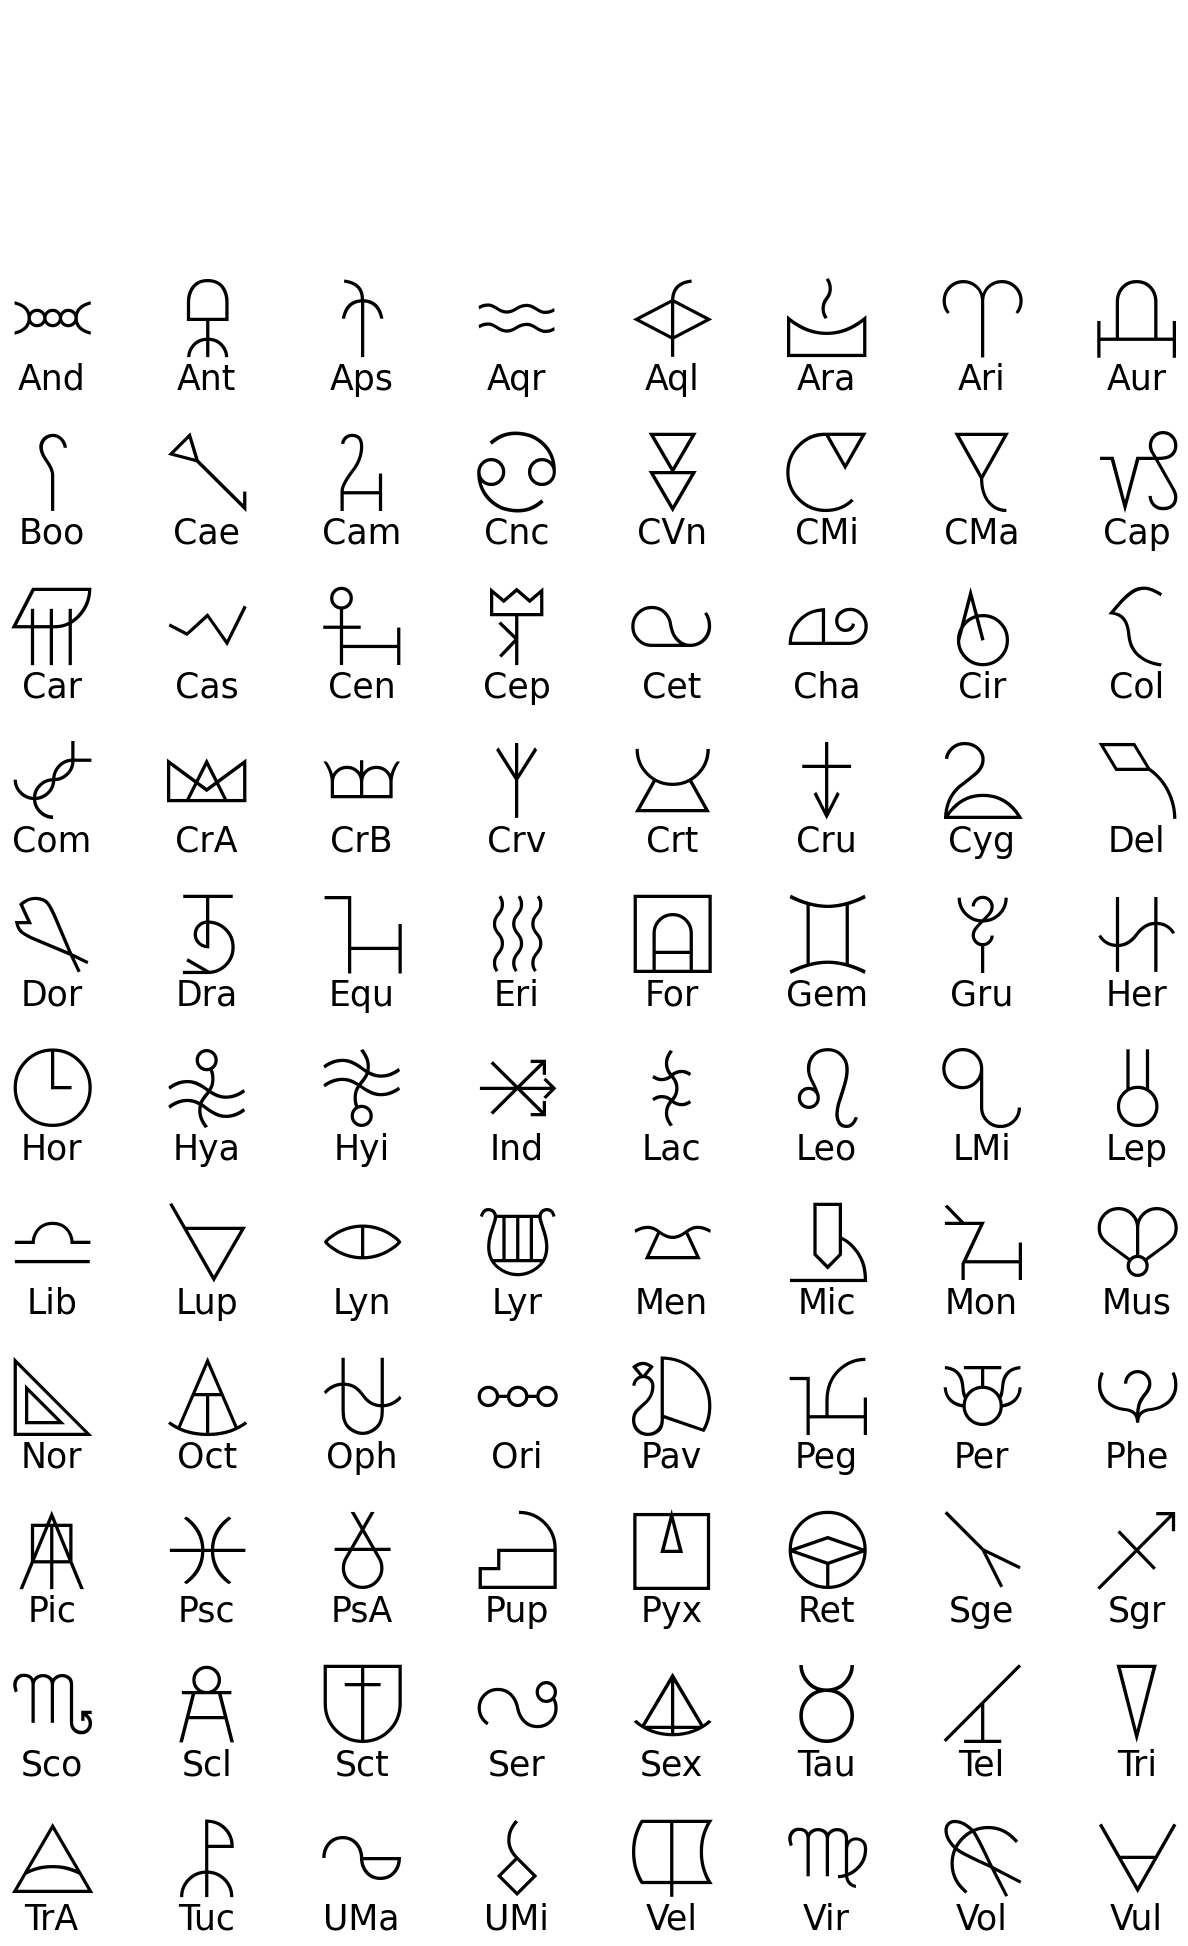

In [ ]:
import matplotlib.pyplot as plt
import matplotlib.font_manager as fm

FONT_PATH = "constellation_custom.ttf"

symbol_prop = fm.FontProperties(fname=FONT_PATH)
font_prop = fm.FontProperties(family='DejaVu Sans')
plt.figure(figsize=(4, 4))
for i, id in enumerate(sorted_IDs):
    j, k = i%8, i//8
    plt.text(0.5*j, - 0.5*k, custom_glyph_ids[id], fontproperties=symbol_prop, fontsize=60, ha="center", va="center")
    plt.text(0.5*j, - 0.5*k - 0.2, id, fontproperties=font_prop, fontsize=25, ha="center", va="center")
 
plt.axis("off")
plt.show()

In [ ]:
import json

In [ ]:
file_name = '/home/giacomo/Downloads/mw.json'

with open(file_name, 'r') as file:
    data = json.load(file)

print(json.dumps(data, indent=4))

{
    "type": "FeatureCollection",
    "features": [
        {
            "type": "Feature",
            "id": "ol1",
            "properties": {},
            "geometry": {
                "type": "MultiPolygon",
                "coordinates": [
                    [
                        [
                            [
                                97.754,
                                34.659
                            ],
                            [
                                97.804,
                                34.571
                            ],
                            [
                                97.6,
                                34.925
                            ],
                            [
                                97.654,
                                34.837
                            ],
                            [
                                97.387,
                                35.059
                            ],
      

In [ ]:
def transform(x,y):
    return x,y

In [ ]:
geom = ((data['features'])[0])['geometry']

In [ ]:
data['features']

[{'type': 'Feature',
  'id': 'ol1',
  'properties': {},
  'geometry': {'type': 'MultiPolygon',
   'coordinates': [[[[97.754, 34.659],
      [97.804, 34.571],
      [97.6, 34.925],
      [97.654, 34.837],
      [97.387, 35.059],
      [97.225, 35.105],
      [97.175, 35.193],
      [97.125, 35.282],
      [96.963, 35.327],
      [96.8, 35.372],
      [96.638, 35.417],
      [96.475, 35.462],
      [96.308, 35.507],
      [96.146, 35.551],
      [95.983, 35.596],
      [95.821, 35.64],
      [95.658, 35.684],
      [95.492, 35.728],
      [95.329, 35.772],
      [95.163, 35.816],
      [95, 35.86],
      [94.833, 35.903],
      [94.779, 35.991],
      [94.725, 36.079],
      [94.563, 36.122],
      [94.396, 36.165],
      [94.342, 36.253],
      [94.288, 36.341],
      [94.121, 36.384],
      [93.954, 36.427],
      [93.896, 36.514],
      [93.842, 36.602],
      [93.788, 36.69],
      [93.729, 36.778],
      [93.675, 36.866],
      [93.621, 36.954],
      [93.563, 37.041],
      [93.508

KeyboardInterrupt: 

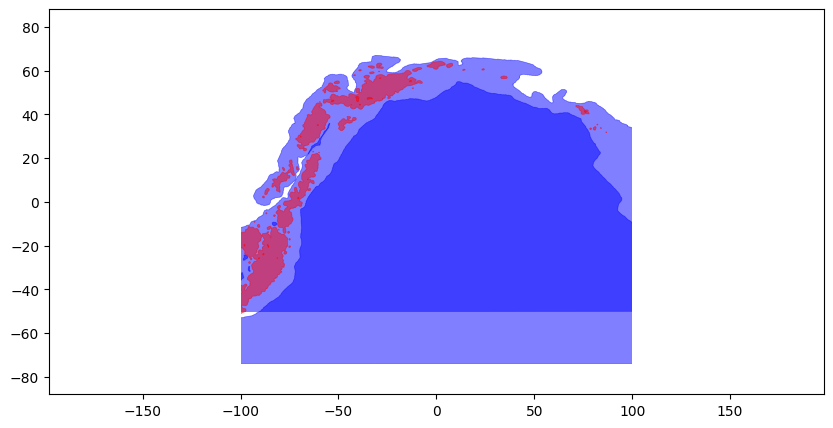

In [ ]:
import json
import matplotlib.pyplot as plt
from matplotlib.patches import Rectangle

# Load your JSON file
with open(file_name) as f:
    data = json.load(f)

fig, ax = plt.subplots(figsize=(10, 5))
box = Rectangle((-100,-80), 200, 160, fill=True, facecolor='w')
ax.add_patch(box)

# Loop over features
for colors, feature in zip(['b', 'r', 'g', 'y', 'k'], data["features"]):
    geometry = feature["geometry"]
    
    if geometry["type"] == "MultiPolygon":
        for polygon in geometry["coordinates"]:
            for ring in polygon:  # outer ring + possible holes
                ra = [pt[0] for pt in ring]
                dec = [pt[1] for pt in ring]
                poly, = ax.fill(ra, dec, color=colors, linewidth=0.5, alpha=0.5)
                poly.set_clip_path(box)

#Restrict everything to the bounding box
for col in ax.collections:
    col.set_clip_path(box)


ax.set_xlabel("Right Ascension (deg)")
ax.set_ylabel("Declination (deg)")
ax.set_title("Milky Way outline")
ax.set_aspect("equal", adjustable="box")
ax.grid(True)

plt.show()


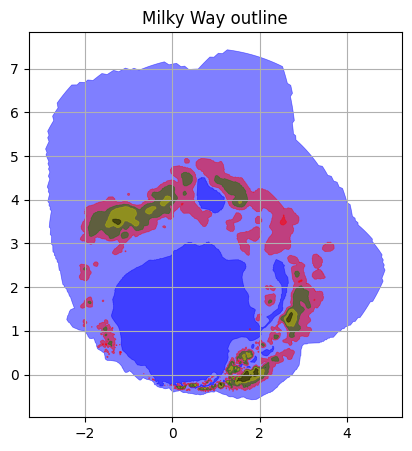

In [ ]:
from HARey.projections import stereo_polar

fig, ax = plt.subplots(figsize=(10, 5))
box = Rectangle((-100,-80), 200, 160, fill=True, facecolor='w')

# Loop over features
for colors, feature in zip(['b', 'r', 'g', 'y', 'k'], data["features"]):
    geometry = feature["geometry"]
    
    if geometry["type"] == "MultiPolygon":
        for polygon in geometry["coordinates"]:
            for ring in polygon:  # outer ring + possible holes
                ra = np.array([pt[0] for pt in ring])
                dec = np.array([pt[1] for pt in ring])
                x, y = stereo_polar(ra, dec)
                poly, = ax.fill(x,y, color=colors, linewidth=0.5, alpha=0.5)


ax.set_title("Milky Way outline")
ax.set_aspect("equal", adjustable="box")
ax.grid(True)

plt.show()

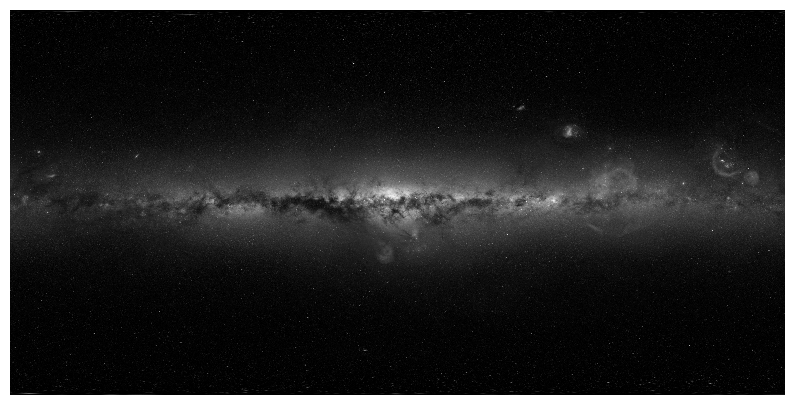

In [ ]:
from matplotlib.image import imread
import matplotlib.pyplot as plt
import numpy as np
from HARey.projections import stereo_polar

# load image (grayscale)
img = imread('AllSkySurvey_Risinger1500.jpg')[:,:,0]  # or your FITS processing

# create RA/Dec grid
ra = np.linspace(0, 360, img.shape[1])
dec = np.linspace(-90, 90, img.shape[0])
RA, DEC = np.meshgrid(ra, dec)

# apply projection
X, Y = RA, DEC

# optional: threshold to one/few light levels
img_thresh = np.clip(0.001*img*2, 0, 1)  # simple bright/faint separation

plt.figure(figsize=(10,5))
plt.pcolormesh(X, Y, img_thresh, shading='auto', cmap='gray')
plt.axis('off')
plt.show()


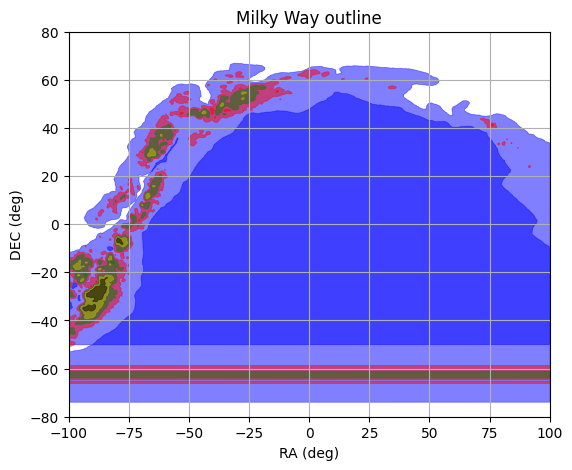

In [ ]:
import json
import matplotlib.pyplot as plt

# Load JSON
with open(file_name) as f:
    data = json.load(f)

# Define bounding box
ra_min, ra_max = -100, 100
dec_min, dec_max = -80, 80

def clip_segment(p1, p2, box):
    """Clip a line segment to a rectangular box.
    Returns list of points inside the box (could be empty or one segment).
    box = (xmin, xmax, ymin, ymax)
    """
    xmin, xmax, ymin, ymax = box
    x1, y1 = p1
    x2, y2 = p2

    # Cohen–Sutherland line clipping algorithm simplified for rectangle
    INSIDE, LEFT, RIGHT, BOTTOM, TOP = 0, 1, 2, 4, 8

    def compute_out_code(x, y):
        code = INSIDE
        if x < xmin: code |= LEFT
        elif x > xmax: code |= RIGHT
        if y < ymin: code |= BOTTOM
        elif y > ymax: code |= TOP
        return code

    code1 = compute_out_code(x1, y1)
    code2 = compute_out_code(x2, y2)
    accept = False

    while True:
        if not (code1 | code2):  # both inside
            accept = True
            break
        elif code1 & code2:  # both outside same side
            break
        else:  # some segment inside
            x, y = 0, 0
            out_code = code1 if code1 else code2
            if out_code & TOP:
                x = x1 + (x2 - x1) * (ymax - y1) / (y2 - y1)
                y = ymax
            elif out_code & BOTTOM:
                x = x1 + (x2 - x1) * (ymin - y1) / (y2 - y1)
                y = ymin
            elif out_code & RIGHT:
                y = y1 + (y2 - y1) * (xmax - x1) / (x2 - x1)
                x = xmax
            elif out_code & LEFT:
                y = y1 + (y2 - y1) * (xmin - x1) / (x2 - x1)
                x = xmin

            if out_code == code1:
                x1, y1 = x, y
                code1 = compute_out_code(x1, y1)
            else:
                x2, y2 = x, y
                code2 = compute_out_code(x2, y2)

    if accept:
        return [(x1, y1), (x2, y2)]
    else:
        return []

# Prepare plot
fig, ax = plt.subplots(figsize=(10, 5))
colors = ['b', 'r', 'g', 'y', 'k']

for i, feature in enumerate(data["features"]):
    color = colors[i % len(colors)]
    geom = feature["geometry"]
    if geom["type"] != "MultiPolygon":
        continue

    for polygon in geom["coordinates"]:
        for ring in polygon:
            clipped_ring = []
            for j in range(len(ring) - 1):
                seg = clip_segment(ring[j], ring[j+1], (ra_min, ra_max, dec_min, dec_max))
                if seg:
                    if not clipped_ring or clipped_ring[-1] != seg[0]:
                        clipped_ring.append(seg[0])
                    clipped_ring.append(seg[1])
            if len(clipped_ring) >= 3:
                xs, ys = zip(*clipped_ring)
                ax.fill(xs, ys, color=color, alpha=0.5, linewidth=0.5)

ax.set_xlim(ra_min, ra_max)
ax.set_ylim(dec_min, dec_max)
ax.set_xlabel("RA (deg)")
ax.set_ylabel("DEC (deg)")
ax.set_title("Milky Way outline")
ax.set_aspect("equal", adjustable="box")
ax.grid(True)
plt.show()



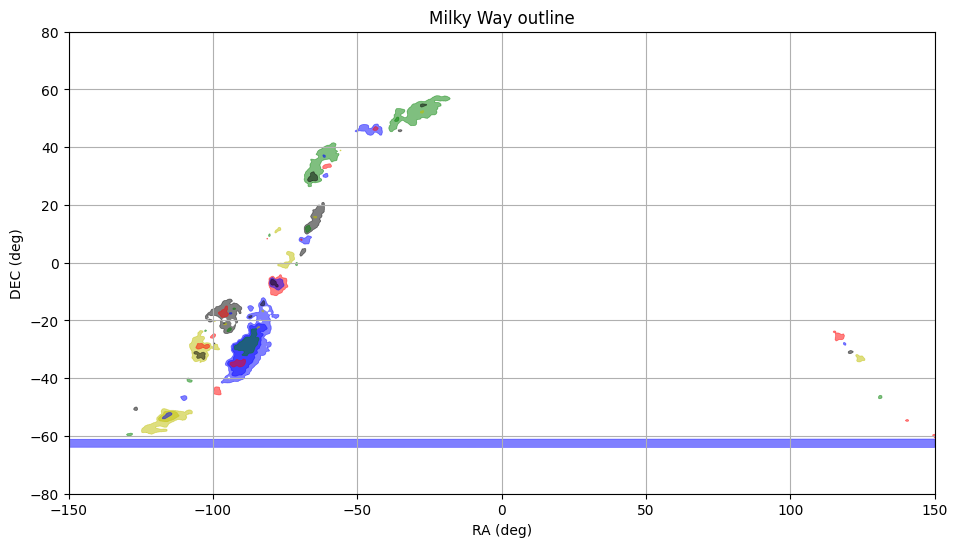

In [ ]:
import json
import matplotlib.pyplot as plt
from shapely.geometry import shape, Polygon, MultiPolygon, box
from shapely.ops import unary_union
from shapely.validation import make_valid

# Load GeoJSON
with open(file_name) as f:
    data = json.load(f)

# Convert GeoJSON features to Shapely geometries
polygons = []
for feature in data["features"]:
    geom = shape(feature["geometry"])
    # Fix invalid geometries
    geom = make_valid(geom)
    if geom.is_empty:
        continue
    # Flatten MultiPolygons
    if geom.geom_type == "Polygon":
        polygons.append(geom)
    elif geom.geom_type == "MultiPolygon":
        polygons.extend(list(geom.geoms))

# Define clipping box (bounding box)
ra_min, ra_max = -150, 150
dec_min, dec_max = -80, 80
clip_box = box(ra_min, dec_min, ra_max, dec_max)

# Clip polygons to bounding box
clipped_polygons = []
for poly in polygons:
    clipped = poly.intersection(clip_box)
    if clipped.is_empty:
        continue
    # Flatten results
    if clipped.geom_type == "Polygon":
        clipped_polygons.append(clipped)
    elif clipped.geom_type == "MultiPolygon":
        clipped_polygons.extend(list(clipped.geoms))

# Plotting
fig, ax = plt.subplots(figsize=(12, 6))
colors = ['b', 'r', 'g', 'y', 'k']

for i, poly in enumerate(clipped_polygons):
    color = colors[i % len(colors)]
    # Exterior
    x, y = poly.exterior.xy
    ax.fill(x, y, color=color, alpha=0.5, linewidth=0.5)
    # Interiors (holes)
    for interior in poly.interiors:
        ix, iy = interior.xy
        ax.fill(ix, iy, color='white')

ax.set_xlim(ra_min, ra_max)
ax.set_ylim(dec_min, dec_max)
ax.set_xlabel("RA (deg)")
ax.set_ylabel("DEC (deg)")
ax.set_title("Milky Way outline")
ax.set_aspect("equal", adjustable="box")
ax.grid(True)
plt.show()

In [ ]:
def one_hot_encode(a):
    # Compute rising edges (consider also the first value if True)
    a_rising = np.r_[False, a]
    rising_edges = np.argwhere(a_rising[1:] & ~a_rising[:-1]).flatten()

    # Compute falling edges (consider also the last value if True)
    a_falling = np.r_[a, False]
    falling_edges = np.argwhere(~a_falling[1:] & a_falling[:-1]).flatten() + 1

    masks = []
    # For each region between edges, return a mask of that region
    for rising, falling in zip(rising_edges, falling_edges):
        # Extend the right border by one
        extended_falling = np.clip(falling + 1, 0, len(a))
        mask = np.zeros_like(a).astype(bool)
        mask[rising:extended_falling] = True
        masks.append(mask)

    return masks

In [ ]:
def merge_segments(segments):
    # Convert to list so we can modify it
    segments = segments[:]
    
    changed = True
    while changed:
        changed = False
        new_segments = []
        used = [False] * len(segments)

        for i in range(len(segments)):
            if used[i]:
                continue

            start_i, end_i = segments[i][0], segments[i][-1]
            merged = False

            for j in range(len(segments)):
                if i != j and not used[j]:
                    start_j, end_j = segments[j][0], segments[j][-1]

                    # If end of i matches start of j → merge
                    if np.all(end_i == start_j):
                        new_segments.append(np.concatenate([segments[i], segments[j]]))
                        used[i] = used[j] = True
                        merged = True
                        break

                    # Optional: handle reverse direction
                    if np.all(end_j == start_i):
                        new_segments.append(np.concatenate([segments[j], segments[i]]))
                        used[i] = used[j] = True
                        merged = True
                        break

            if not merged and not used[i]:
                new_segments.append(segments[i])
                used[i] = True

        segments = new_segments

    return segments

In [ ]:
def rect_param(p, borders):
    x, y = p
    min_ra, max_ra, min_dec, max_dec = borders
    H, W = max_dec - min_dec, max_ra - min_ra
    
    closest_border = np.argmin(np.abs((y-min_dec, x-max_ra, y - max_dec, x - max_ra)))
    rp = (x - min_ra, y - min_dec + W, max_ra - x + W + H, max_dec - y + 2*W + H )

    return rp[closest_border]

def rect_walk(t, borders):

    min_ra, max_ra, min_dec, max_dec = borders
    H, W = max_dec - min_dec, max_ra - min_ra

    PERIM = 2* (H + W)
    t = t % PERIM
    
    x, y = np.zeros_like(t), np.zeros_like(t)
    bottom = t < W
    x[bottom], y[bottom] = min_ra + t[bottom], min_dec

    right = (t >= W) & (t < W + H)
    x[right], y[right] = max_ra, min_dec - W + t[right]

    top = (t >= W + H) & (t < 2*W + H)
    x[top], y[top] = max_ra + H + W - t[top], max_dec

    left = (t >= 2*W + H)
    x[left], y[left] = min_ra, max_dec + 2*W + H - t[left] 

    return np.array((x,y))
    

In [ ]:
def wrapped_dist(a, b, m):
    
    diff = np.abs(a - b) % m
    wrapped_dist = np.minimum(diff, m - diff)
    
    return wrapped_dist

In [ ]:
def draw_milky_way(rings, borders):
    min_ra, max_ra, min_dec, max_dec = borders

    H, W = max_dec - min_dec, max_ra - min_ra
    # Clip it to the bounding box
    inside = lambda x,y : (x >= min_ra) & (x <= max_ra) & (y >= min_dec) & (y <= max_dec)

    closed_rings = []
    segments = []

    for ring in rings:

        ring = np.array(ring)
        inside_mask = inside(*ring.T)

        if np.all(inside_mask):
            closed_rings.append(ring)
        else:
            for mask in one_hot_encode(inside_mask):
                segments.append(ring[mask]) 

    # Merge the open-end segments to close the rings 
    segments = merge_segments(segments)

    # Now the only discontinuities are on the border
    ring = segments[0]

    segments = segments[1:]
    #segments.append([ring[0]])
    PERIM = 2*(H + W)

    start_rp = np.array([rect_param(segment[0], borders) for segment in segments])
    end_rp = np.array([rect_param(segment[-1], borders) for segment in segments])

    while len(segments) > 0:

        ring_end = ring[-1]
        ring_end_rp = rect_param(ring_end, borders)

        start_dists = wrapped_dist(start_rp, ring_end_rp, PERIM)
        closest_start, closest_start_index = np.min(start_dists), np.argmin(start_dists)

        end_dists = wrapped_dist(end_rp, ring_end_rp, PERIM)
        closest_end, closest_end_index = np.min(end_dists), np.argmin(end_dists)

        if closest_start < closest_end:
            index = closest_start_index
            segment_to_append = segments[index]
            join_rp = start_rp[index]
        else:
            index = closest_end_index
            segment_to_append = segments[index][::-1]
            join_rp = end_rp[index]

        join_rp = join_rp + PERIM if join_rp < ring_end_rp else join_rp
        
        join_path = np.linspace(ring_end_rp, join_rp, 100)
        ring = np.concatenate([ring, rect_walk(join_path, borders).T, segment_to_append])
        #ring = np.concatenate([ring, segment_to_append])
        segments.pop(index)
        start_rp = np.delete(start_rp, index, axis=0)
        end_rp = np.delete(end_rp, index, axis=0)

    #Close the ring
    ring_start_rp = rect_param(ring[0], borders)
    ring_end_rp = rect_param(ring[-1], borders)
    print(ring_start_rp, ring_end_rp, PERIM)

    ring_start_rp = ring_start_rp + PERIM if ring_start_rp < ring_end_rp else ring_start_rp
    
    join_path = np.linspace(ring_end_rp, ring_start_rp, 100)
    #ring = np.concatenate([ring, rect_walk(join_path, borders).T])

    closed_rings.append(ring)
        
    return closed_rings

In [ ]:
rings = data['features'][0]['geometry']['coordinates'][0]

148.156 126.463 480


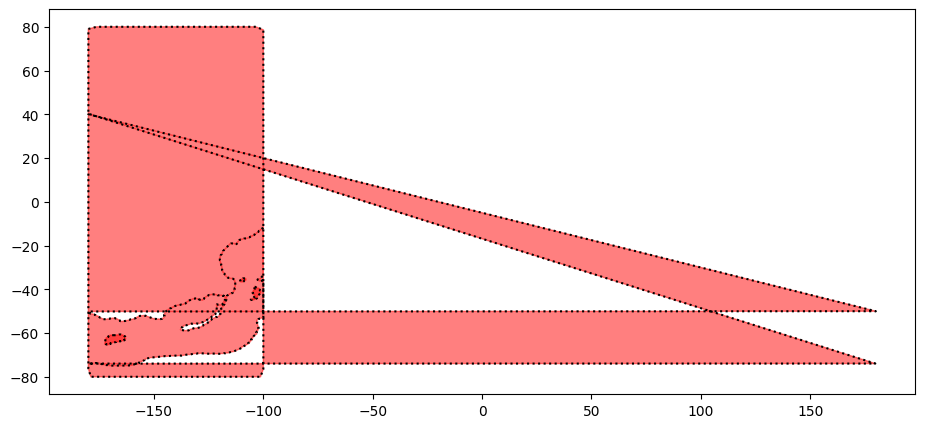

In [ ]:
closed_rings = draw_milky_way(rings, (-180, -100, -80, 80))
fig, ax = plt.subplots(figsize = (15,5))

for ring in closed_rings:
    x,y = zip(*ring)
    ax.fill(x,y, c='red', alpha=0.5)
    ax.plot(x, y, 'k:')

ax.set_aspect('equal')
plt.show()

In [ ]:
def get_segments(rings, borders):
    min_ra, max_ra, min_dec, max_dec = borders

    H, W = max_dec - min_dec, max_ra - min_ra
    # Clip it to the bounding box
    inside = lambda x,y : (x >= min_ra) & (x <= max_ra) & (y >= min_dec) & (y <= max_dec)

    segments = []

    for ring in rings:

        ring = np.array(ring)
        inside_mask = inside(*ring.T)

        if np.all(inside_mask):
            segments.append(ring)
        else:
            for mask in one_hot_encode(inside_mask):
                segments.append(ring[mask]) 

    
    return merge_segments(segments)

def join_segs(segments, joins, reverse=[]):
    rings = []
    for ring_indexes in joins:
        ring = []
        for index in ring_indexes:
            if index in reverse:
                ring.extend(list(segments[index][::-1]))
            else:
                ring.extend(list(segments[index]))

        rings.append(np.array(ring))

    return rings
    

In [ ]:
shapes = []

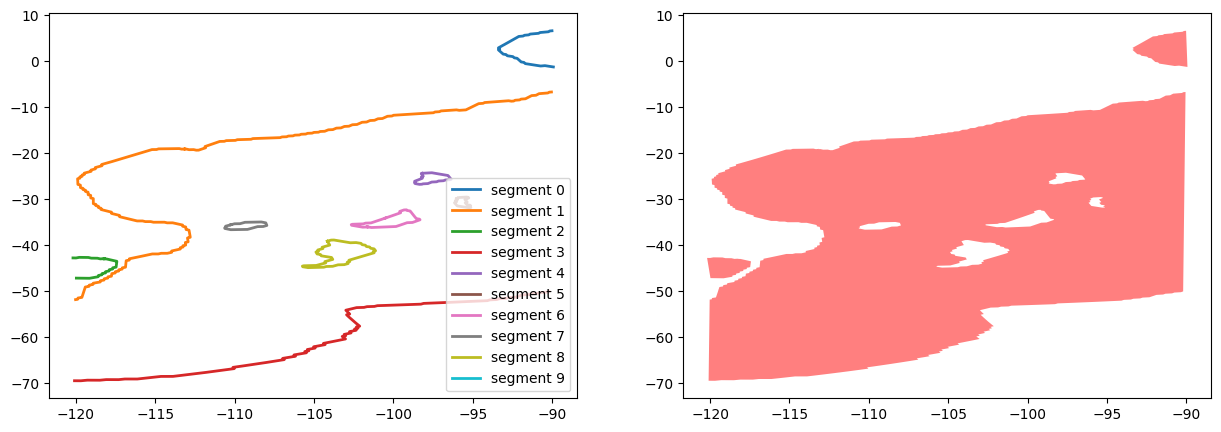

In [ ]:
segments = get_segments(rings, (-120, -90, -80, 80))
#
fig, (ax1, ax2) = plt.subplots(ncols = 2, figsize = (15,5))

segments = [*segments, [segments[1][-1]]]

for i, segment in enumerate(segments):
    x,y = zip(*segment)
    ax1.plot(x, y, '-', lw=2, label=f'segment {i}')

shape_rings = join_segs(segments, joins=[[0],[2],[1,9,4,9,5,9,6,9,7,9,8,9,3]], reverse=[3, 4,5,6,7,8])
for ring in shape_rings:
    x,y = zip(*ring)
    ax2.fill(x, y, 'r', alpha=0.5)

ax1.set_aspect('auto')
ax1.legend()
plt.show()

In [ ]:
segments

[array([[-9.0012e+01,  6.6070e+00],
        [-9.0146e+01,  6.5650e+00],
        [-9.0192e+01,  6.4790e+00],
        [-9.0233e+01,  6.3920e+00],
        [-9.0367e+01,  6.3500e+00],
        [-9.0500e+01,  6.3090e+00],
        [-9.0633e+01,  6.2670e+00],
        [-9.0767e+01,  6.2260e+00],
        [-9.0812e+01,  6.1390e+00],
        [-9.0858e+01,  6.0530e+00],
        [-9.0992e+01,  6.0110e+00],
        [-9.1125e+01,  5.9700e+00],
        [-9.1258e+01,  5.9290e+00],
        [-9.1392e+01,  5.8870e+00],
        [-9.1433e+01,  5.8010e+00],
        [-9.1479e+01,  5.7150e+00],
        [-9.1613e+01,  5.6740e+00],
        [-9.1746e+01,  5.6330e+00],
        [-9.1787e+01,  5.5470e+00],
        [-9.1833e+01,  5.4610e+00],
        [-9.1967e+01,  5.4200e+00],
        [-9.2100e+01,  5.3790e+00],
        [-9.2146e+01,  5.2930e+00],
        [-9.2187e+01,  5.2070e+00],
        [-9.2233e+01,  5.1210e+00],
        [-9.2275e+01,  5.0350e+00],
        [-9.2321e+01,  4.9490e+00],
        [-9.2367e+01,  4.863

In [ ]:
shapes.append(shape_rings)

In [ ]:
len(shapes)

1

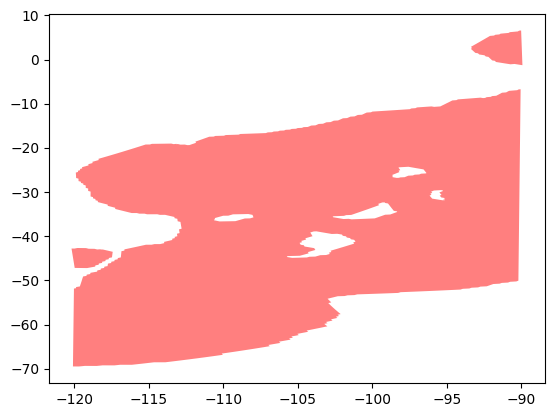

In [ ]:
for shape in shapes:
    for ring in shape:
        x,y = zip(*ring)
        plt.fill(x,y, 'r', alpha=0.5)

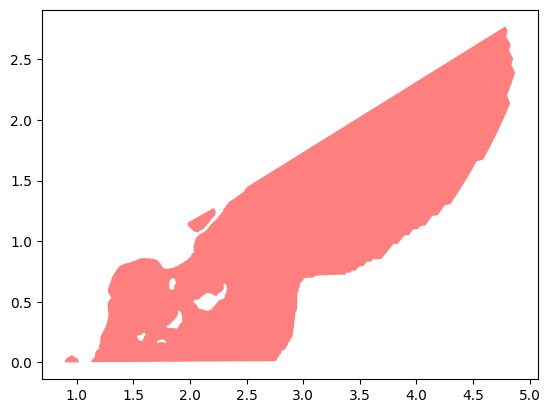

In [ ]:
for shape in shapes:
    for ring in shape:
        x,y = zip(*ring)
        x,y = stereo_polar(x,y)
        plt.fill(x,y, 'r', alpha=0.5)

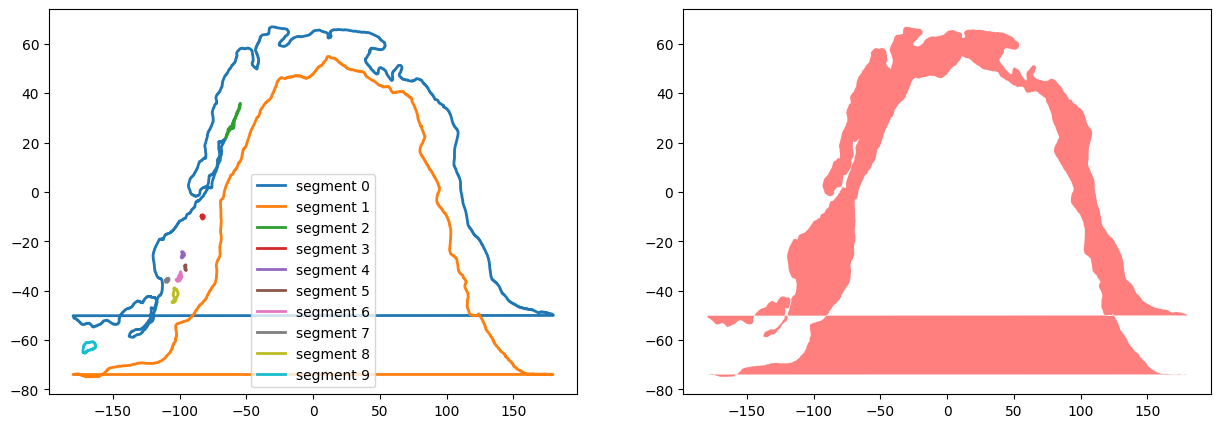

In [ ]:
fig, (ax1, ax2) = plt.subplots(ncols = 2, figsize = (15,5))



for i, segment in enumerate(rings):
    x,y = zip(*segment)
    ax1.plot(x, y, '-', lw=2, label=f'segment {i}')

shape_rings = join_segs(rings, joins=[[0,1]], reverse=[1])
for ring in shape_rings:
    x,y = zip(*ring)
    ax2.fill(x, y, 'r', alpha=0.5)

ax1.set_aspect('auto')
ax1.legend()
plt.show()

In [ ]:
print(rings[0][0])
print(rings[0][-1])
first_seg = rings[0][:-1]

[97.754, 34.659]
[97.754, 34.659]


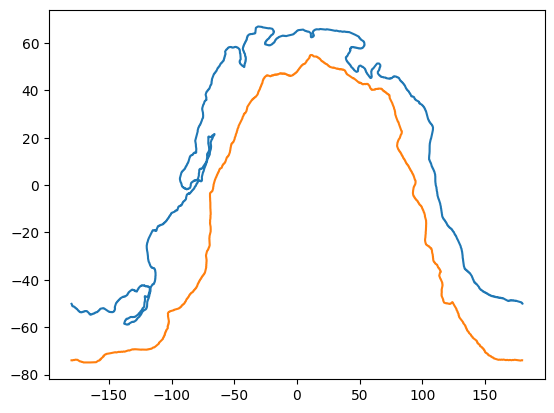

In [ ]:
first_seg = np.array(rings[0][:-1])
dec, ra = first_seg.T[1], first_seg.T[0]

disc = np.argwhere(np.abs(np.diff(ra))>180)[0][0] + 1 

n = len(ra)
mask = (np.arange(n) + disc) % n

ra, dec = ra[mask], dec[mask]
first_seg = np.array((ra,dec)).T

plt.plot(ra,dec)

second_seg = np.array(rings[1][:-1])
dec, ra = second_seg.T[1], second_seg.T[0]

disc = np.argwhere(np.abs(np.diff(ra))>180)[0][0] + 1 

n = len(ra)
mask = (np.arange(n) + disc) % n

ra, dec = ra[mask], dec[mask]
second_seg = np.array((ra,dec)).T

plt.plot(ra,dec)



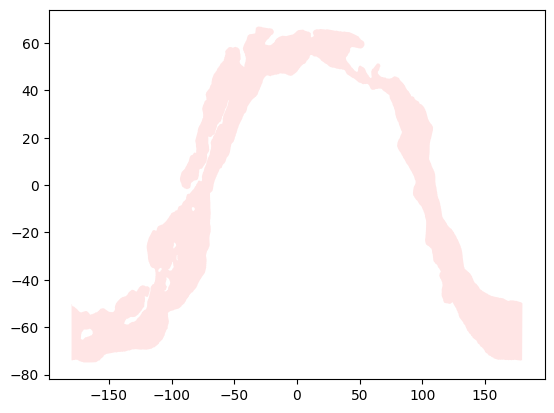

In [ ]:
start_point = [first_seg[0]]
ext_ring = np.concatenate((first_seg, second_seg[::-1], start_point))

for ring in rings[2:]:
    ext_ring = np.concatenate((ext_ring, ring[::-1], start_point))
    
x,y = zip(*ext_ring)
plt.fill(x,y, 'r', alpha=0.1)
plt.show()

In [ ]:
np.save('milky_way_profile.npy',ext_ring)

In [ ]:
luminosity_levels = [data['features'][i]['geometry']['coordinates'][0] for i in range(5)]

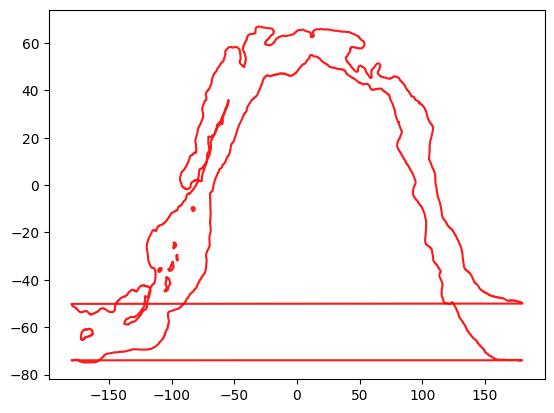

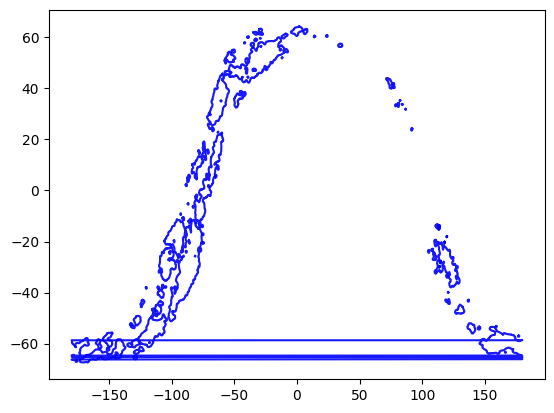

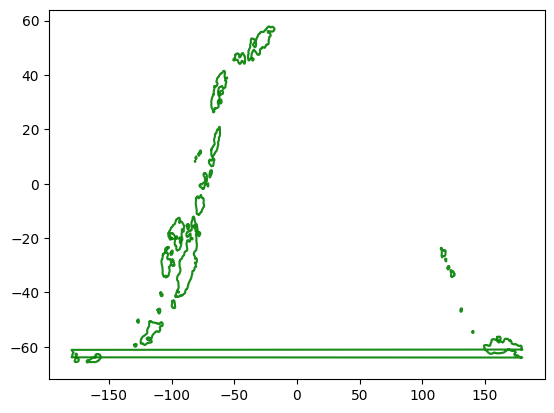

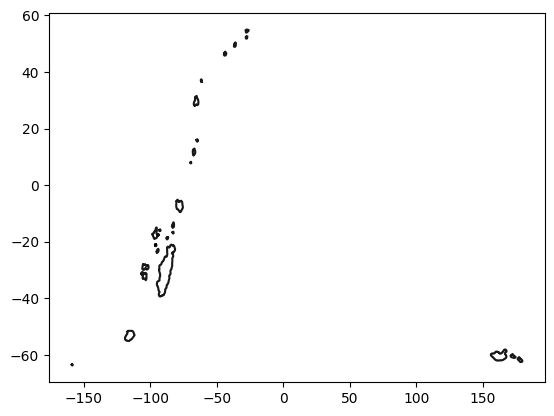

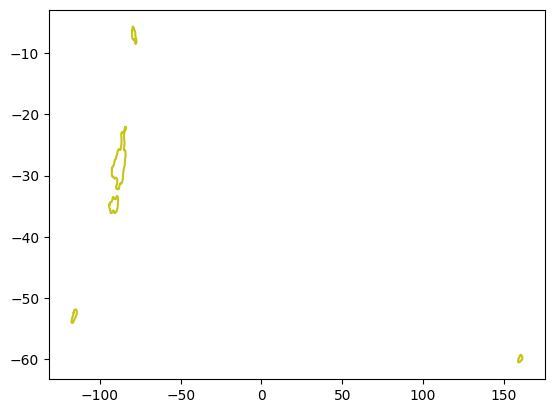

In [ ]:
for level, color in zip(luminosity_levels, ['r', 'b', 'g', 'k', 'y']):
    for ring in level:
        x,y = zip(*ring)
        plt.plot(x,y, color, alpha=0.9)
    plt.show()

In [ ]:
x = np.linspace(0,10,101)
x = x + 2*np.sin(2*x)

In [ ]:
def cut_segments(x, delims):
    # Mask the values where the condition is true
    mask = (x>delims[0]) & (x<delims[1])
    # Get the true values and also the first 
    a_rising = np.r_[False, mask]
    rising_edges = np.argwhere(a_rising[1:] & ~a_rising[:-1]).flatten()
    a_falling = np.r_[mask, False]
    falling_edges = np.argwhere(~a_falling[1:] & a_falling[:-1]).flatten() + 1

    closest_rising = []    
    for point in rising_edges:
        if point==0:
            closest_rising.append(0)
        else:
            closest_delim = delims[np.argmin([np.abs(x[point] - delim) for delim in delims])]
            candidates = [point -1, point, point + 1]
            closest_rising.append(candidates[np.argmin(np.abs(x[candidates] - closest_delim))])
    
    closest_falling = []    
    for point in falling_edges:
        if point==len(mask):
            closest_falling.append(0)
        else:
            closest_delim = delims[np.argmin([np.abs(x[point] - delim) for delim in delims])]
            candidates = [point -1, point, point + 1]
            closest_falling.append(candidates[np.argmin(np.abs(x[candidates] - closest_delim))])
    
    masks = []
    for rising, falling in zip(closest_rising, closest_falling):
        mask = np.zeros_like(mask).astype(bool)
        mask[rising:falling+1] = True
        masks.append(mask)

    return masks

In [ ]:
def get_segments(rings, borders):
    segments = []

    for ring in rings:
        ring = np.array(ring)
        ra = ring[:,0]
        if np.all((ra > borders[0]) & (ra < borders[1])):
            segments.append(ring)
        else:
            for mask in cut_segments(ra, borders):
                segments.append(ring[mask]) 

    
    return segments

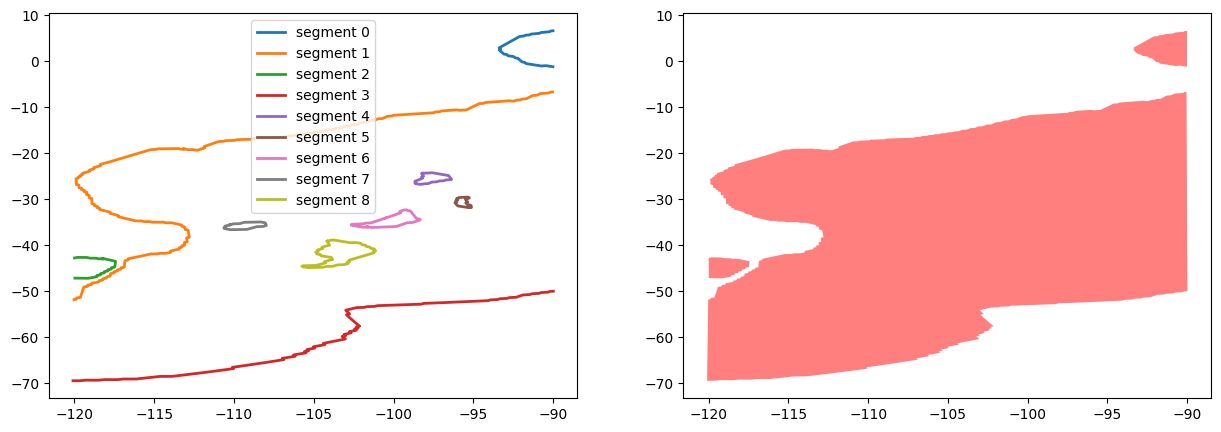

In [ ]:
segments = get_segments(rings, (-120, -90))
#
fig, (ax1, ax2) = plt.subplots(ncols = 2, figsize = (15,5))

#segments = [*segments, [segments[1][-1]]]

for i, segment in enumerate(segments):
    x,y = zip(*segment)
    ax1.plot(x, y, '-', lw=2, label=f'segment {i}')
    

shape_rings = join_segs(segments, joins=[[0],[2], [1,3]], reverse=[3])
for ring in shape_rings:
    x,y = zip(*ring)
    ax2.fill(x, y, 'r', alpha=0.5)

ax1.set_aspect('auto')
ax1.legend()
plt.show()

In [ ]:
segments[2][0]

array([-119.975,  -47.177])

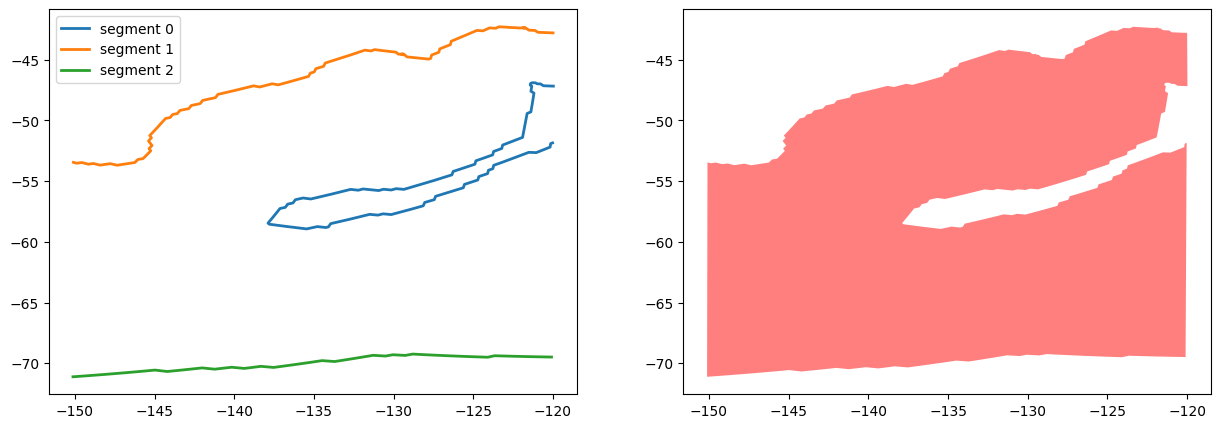

In [ ]:
segments = get_segments(rings, (-150, -120))
#
fig, (ax1, ax2) = plt.subplots(ncols = 2, figsize = (15,5))

#segments = [*segments, [segments[1][-1]]]

for i, segment in enumerate(segments):
    x,y = zip(*segment)
    ax1.plot(x, y, '-', lw=2, label=f'segment {i}')
    

shape_rings = join_segs(segments, joins=[[0,1,2]], reverse=[2])
for ring in shape_rings:
    x,y = zip(*ring)
    ax2.fill(x, y, 'r', alpha=0.5)

ax1.set_aspect('auto')
ax1.legend()
plt.show()

In [ ]:
segments[1][0]

array([-119.996,  -42.793])

In [ ]:
segments[2][0]

array([-120.092,  -69.492])

In [ ]:
shapes.append(shape_rings)

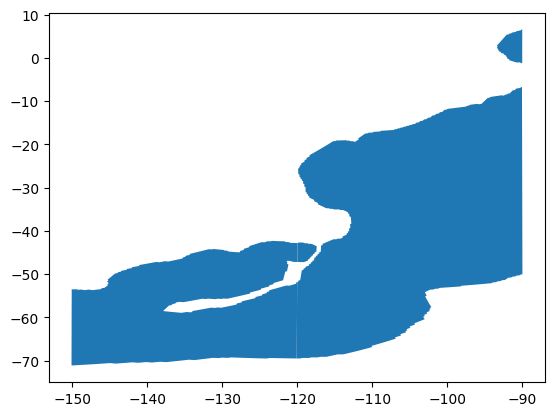

In [ ]:
from matplotlib.collections import PolyCollection
fig, ax = plt.subplots()
polys = []
for shape in shapes:
    for ring in shape:
        polys.append(ring)

pc = PolyCollection(polys)
ax.add_collection(pc)
ax.autoscale_view()
plt.show()